# RQ4 Assignment 4: Crash Injury Classification

Research question:

**Can high-injury crashes be classified using traffic-unit involvement and enriched traffic-volume variables?**

This notebook compares:

1. A baseline model using original crash variables only.
2. An enriched model using crash variables plus traffic-volume variables from Transport for NSW.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load Dataset

Use the analysis-ready enriched dataset created from:

- NSW crash preprocessed dataset
- Traffic station reference dataset
- Yearly traffic count summary dataset

In [4]:
DATA_PATH = Path("nsw_crash_traffic_volume_analysis_ready.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
df.head()

(47092, 95)


,crash_row_id,Year of crash,Month of crash,Day of week of crash,Street of crash,Street type,Town,LGA,Latitude,Longitude,...,light_vehicles_all_days,light_vehicles_am_peak,light_vehicles_pm_peak,light_vehicles_weekdays,light_vehicles_weekends,unclassified_all_days,unclassified_am_peak,unclassified_pm_peak,unclassified_weekdays,unclassified_weekends
0,1,2020,January,Friday,PACIFIC,HWY,BOM BOM,Clarence Valley,-29.745446,152.993909,...,NaN,NaN,NaN,NaN,NaN,6278.0,1486.0,1303.0,6630.0,5603.0
1,3,2020,January,Sunday,MARSDEN,RD,EASTWOOD,Ryde,-33.796520,151.065251,...,NaN,NaN,NaN,NaN,NaN,11230.0,2832.0,3174.0,11560.0,10499.0
2,5,2020,January,Friday,BUCKETTS,WAY,TWELVE MILE CREEK,Port Stephens,-32.643762,151.868062,...,5696.0,1390.0,1740.0,5532.0,6210.0,NaN,NaN,NaN,NaN,NaN
3,6,2020,January,Tuesday,YAMBA,RD,MACLEAN,Clarence Valley,-29.441917,153.212872,...,8258.0,2244.0,2622.0,9004.0,6428.0,NaN,NaN,NaN,NaN,NaN
4,9,2020,January,Monday,KIDMAN,WAY,THARBOGANG,Griffith,-34.249547,145.980776,...,4704.0,1300.0,1526.0,5172.0,3266.0,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()
df.isna().mean().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47092 entries, 0 to 47091
Data columns (total 95 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   crash_row_id                         47092 non-null  int64  
 1   Year of crash                        47092 non-null  int64  
 2   Month of crash                       47092 non-null  object 
 3   Day of week of crash                 47092 non-null  object 
 4   Street of crash                      47092 non-null  object 
 5   Street type                          47092 non-null  object 
 6   Town                                 47092 non-null  object 
 7   LGA                                  47092 non-null  object 
 8   Latitude                             47092 non-null  float64
 9   Longitude                            47092 non-null  float64
 10  Degree of crash                      47092 non-null  object 
 11  No. of traffic units involve

heavy_vehicles_weekends         0.786906
light_vehicles_weekends         0.786269
light_vehicles_weekdays         0.785123
heavy_vehicle_share_all_days    0.784443
heavy_vehicles_all_days         0.784443
light_vehicles_pm_peak          0.784443
light_vehicles_am_peak          0.784443
light_vehicles_all_days         0.784443
heavy_vehicles_weekdays         0.784443
heavy_vehicles_pm_peak          0.784443
heavy_vehicles_am_peak          0.784443
all_vehicles_weekends           0.783764
all_vehicles_weekdays           0.782044
all_vehicles_pm_peak            0.781959
all_vehicles_am_peak            0.781959
unclassified_weekends           0.223817
unclassified_weekdays           0.218615
unclassified_pm_peak            0.218615
unclassified_am_peak            0.218615
unclassified_all_days           0.218041
dtype: float64

## 2. Create Classification Target

`Total_casualties` is treated as an engineered feature:

`No. killed + No. seriously injured + No. moderately injured + No. minor-other injured`

For classification:

- `0` = low/no injury crash, where `Total_casualties` is 0 or 1
- `1` = high-injury crash, where `Total_casualties` is 2 or more

In [7]:
casualty_components = [
    "No. killed",
    "No. seriously injured",
    "No. moderately injured",
    "No. minor-other injured",
]

for col in casualty_components:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

if "Total_casualties" not in df.columns:
    df["Total_casualties"] = df[casualty_components].sum(axis=1)
else:
    df["Total_casualties"] = pd.to_numeric(df["Total_casualties"], errors="coerce")

df["high_injury_crash"] = (df["Total_casualties"] >= 2).astype(int)

df[["Total_casualties", "high_injury_crash"]].head()

,Total_casualties,high_injury_crash
0,2,1
1,2,1
2,1,0
3,1,0
4,2,1


In [8]:
target_counts = df["high_injury_crash"].value_counts().sort_index()
target_rates = df["high_injury_crash"].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({"count": target_counts, "rate": target_rates})
target_summary.index = ["Low/no injury (0-1 casualties)", "High injury (2+ casualties)"]
target_summary

,count,rate
Low/no injury (0-1 casualties),41347,0.878005
High injury (2+ casualties),5745,0.121995


## 3. Exploratory Data Analysis

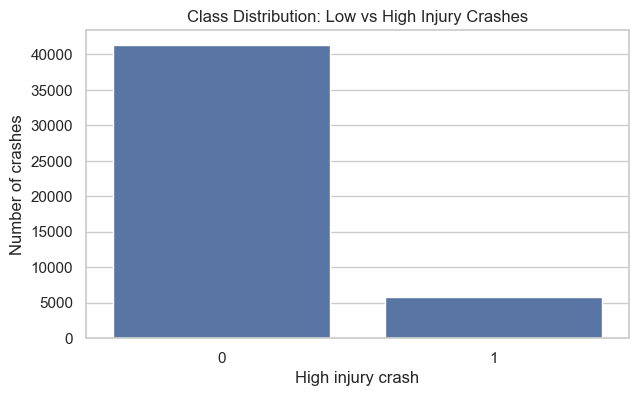

In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="high_injury_crash")
plt.title("Class Distribution: Low vs High Injury Crashes")
plt.xlabel("High injury crash")
plt.ylabel("Number of crashes")
plt.show()

,No. of traffic units involved,count,high_injury_rate
0,1,9542,0.055334
1,2,31165,0.122541
2,3,4935,0.206282
3,4,1071,0.238095
4,5,244,0.299180
5,6,76,0.355263
6,7,30,0.400000
7,8,13,0.461538
8,9,3,0.666667
9,10,8,0.500000


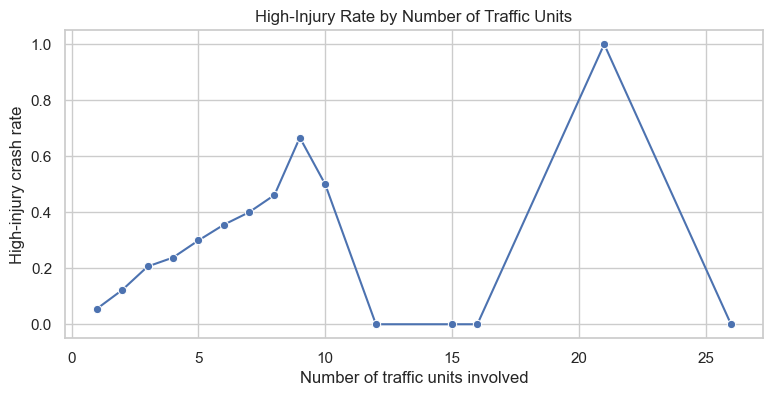

In [11]:
traffic_units_col = "No. of traffic units involved"
df[traffic_units_col] = pd.to_numeric(df[traffic_units_col], errors="coerce")

tu_summary = (
    df.groupby(traffic_units_col)["high_injury_crash"]
    .agg(count="count", high_injury_rate="mean")
    .reset_index()
    .sort_values(traffic_units_col)
)

display(tu_summary.head(15))

plt.figure(figsize=(9, 4))
sns.lineplot(data=tu_summary, x=traffic_units_col, y="high_injury_rate", marker="o")
plt.title("High-Injury Rate by Number of Traffic Units")
plt.xlabel("Number of traffic units involved")
plt.ylabel("High-injury crash rate")
plt.show()

,traffic_volume_band,count,high_injury_rate
0,"(99.999, 16501.0]",9429,0.143387
1,"(16501.0, 28830.0]",9429,0.121752
2,"(28830.0, 43094.0]",9403,0.113155
3,"(43094.0, 66171.0]",9479,0.119422
4,"(66171.0, 309752.0]",9352,0.112169


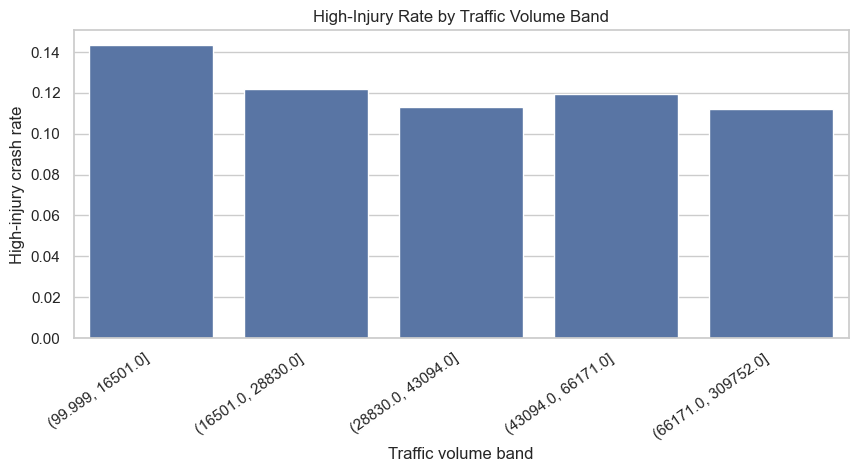

In [12]:
traffic_volume_col = "all_vehicles_all_days"
df[traffic_volume_col] = pd.to_numeric(df[traffic_volume_col], errors="coerce")

df["traffic_volume_band"] = pd.qcut(
    df[traffic_volume_col],
    q=5,
    duplicates="drop"
)

volume_summary = (
    df.groupby("traffic_volume_band", observed=True)["high_injury_crash"]
    .agg(count="count", high_injury_rate="mean")
    .reset_index()
)

display(volume_summary)

plt.figure(figsize=(10, 4))
sns.barplot(data=volume_summary, x="traffic_volume_band", y="high_injury_rate")
plt.title("High-Injury Rate by Traffic Volume Band")
plt.xlabel("Traffic volume band")
plt.ylabel("High-injury crash rate")
plt.xticks(rotation=35, ha="right")
plt.show()

,matched_station_road_classification,count,high_injury_rate
0,State,40159,0.121965
1,Regional,4927,0.121372
2,Local,2006,0.124128


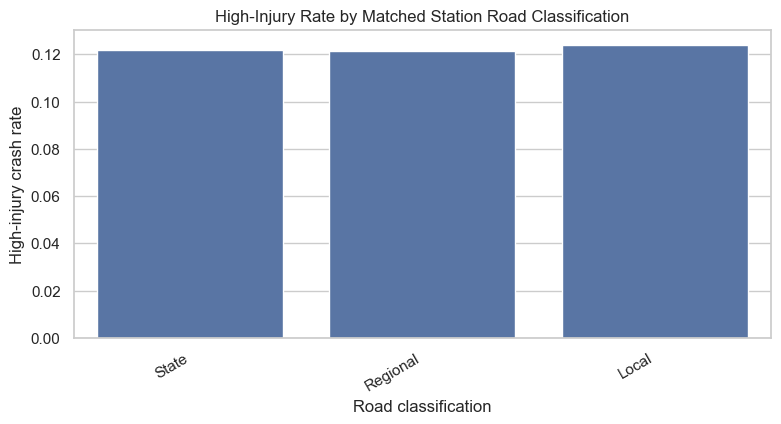

In [13]:
road_class_col = "matched_station_road_classification"

if road_class_col in df.columns:
    road_class_summary = (
        df.groupby(road_class_col)["high_injury_crash"]
        .agg(count="count", high_injury_rate="mean")
        .sort_values("count", ascending=False)
        .reset_index()
    )
    display(road_class_summary)

    plt.figure(figsize=(9, 4))
    sns.barplot(data=road_class_summary, x=road_class_col, y="high_injury_rate")
    plt.title("High-Injury Rate by Matched Station Road Classification")
    plt.xlabel("Road classification")
    plt.ylabel("High-injury crash rate")
    plt.xticks(rotation=30, ha="right")
    plt.show()

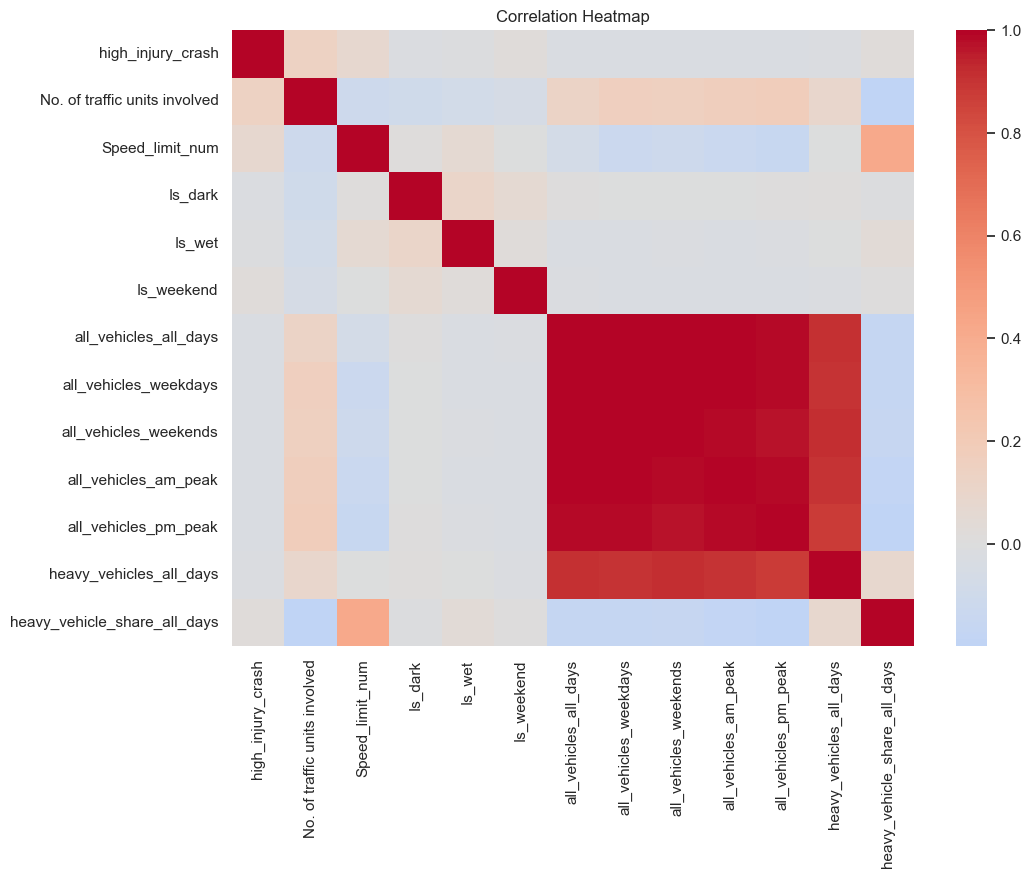

In [14]:
numeric_for_corr = [
    "high_injury_crash",
    "No. of traffic units involved",
    "Speed_limit_num",
    "Is_dark",
    "Is_wet",
    "Is_weekend",
    "all_vehicles_all_days",
    "all_vehicles_weekdays",
    "all_vehicles_weekends",
    "all_vehicles_am_peak",
    "all_vehicles_pm_peak",
    "heavy_vehicles_all_days",
    "heavy_vehicle_share_all_days",
]
numeric_for_corr = [c for c in numeric_for_corr if c in df.columns]

corr_df = df[numeric_for_corr].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(11, 8))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.show()

## 4. Define Baseline and Enriched Features

In [16]:
baseline_numeric_features = [
    "No. of traffic units involved",
    "Speed_limit_num",
    "Is_dark",
    "Is_wet",
    "Is_weekend",
    "Month_num",
    "Day_num",
]

baseline_categorical_features = [
    "Urbanisation",
    "Type of location",
    "Road surface",
    "Weather",
    "Natural lighting",
]

enriched_numeric_features = baseline_numeric_features + [
    "all_vehicles_all_days",
    "all_vehicles_weekdays",
    "all_vehicles_weekends",
    "all_vehicles_am_peak",
    "all_vehicles_pm_peak",
    "heavy_vehicles_all_days",
    "heavy_vehicle_share_all_days",
]

enriched_categorical_features = baseline_categorical_features + [
    "matched_station_road_classification",
    "matched_station_road_hierarchy",
    "matched_station_lane_count",
]

def existing_columns(cols):
    return [c for c in cols if c in df.columns]

baseline_numeric_features = existing_columns(baseline_numeric_features)
baseline_categorical_features = existing_columns(baseline_categorical_features)
enriched_numeric_features = existing_columns(enriched_numeric_features)
enriched_categorical_features = existing_columns(enriched_categorical_features)

print("Baseline numeric:", baseline_numeric_features)
print("Baseline categorical:", baseline_categorical_features)
print("Enriched numeric:", enriched_numeric_features)
print("Enriched categorical:", enriched_categorical_features)

Baseline numeric: ['No. of traffic units involved', 'Speed_limit_num', 'Is_dark', 'Is_wet', 'Is_weekend', 'Month_num', 'Day_num']
Baseline categorical: ['Urbanisation', 'Type of location', 'Road surface', 'Weather', 'Natural lighting']
Enriched numeric: ['No. of traffic units involved', 'Speed_limit_num', 'Is_dark', 'Is_wet', 'Is_weekend', 'Month_num', 'Day_num', 'all_vehicles_all_days', 'all_vehicles_weekdays', 'all_vehicles_weekends', 'all_vehicles_am_peak', 'all_vehicles_pm_peak', 'heavy_vehicles_all_days', 'heavy_vehicle_share_all_days']
Enriched categorical: ['Urbanisation', 'Type of location', 'Road surface', 'Weather', 'Natural lighting', 'matched_station_road_classification', 'matched_station_road_hierarchy', 'matched_station_lane_count']


## 5. Train/Test Split

In [18]:
target = "high_injury_crash"

all_model_features = sorted(set(enriched_numeric_features + enriched_categorical_features))
model_df = df[all_model_features + [target]].copy()
model_df = model_df.dropna(subset=[target])

X = model_df[all_model_features]
y = model_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, y_train.value_counts(normalize=True).to_dict())
print("Test:", X_test.shape, y_test.value_counts(normalize=True).to_dict())

Train: (32964, 22) {0: 0.8780184443635481, 1: 0.12198155563645188}
Test: (14128, 22) {0: 0.8779728199320498, 1: 0.12202718006795017}


## 6. Preprocessing and Model Pipelines

In [20]:
def make_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


def make_pipeline(model, numeric_features, categorical_features):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_features, categorical_features)),
            ("model", model),
        ]
    )

## 7. Model Evaluation Helper

In [22]:
def evaluate_model(name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
    else:
        y_score = None

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test_data, y_pred),
        "precision": precision_score(y_test_data, y_pred, zero_division=0),
        "recall": recall_score(y_test_data, y_pred, zero_division=0),
        "f1": f1_score(y_test_data, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_data, y_score) if y_score is not None else np.nan,
    }
    
    print("\n", name)
    print(classification_report(y_test_data, y_pred, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_test_data, y_pred)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    
    if y_score is not None:
        RocCurveDisplay.from_predictions(y_test_data, y_score)
        plt.title(f"ROC Curve: {name}")
        plt.show()
    
    return results

## 8. Baseline Models: Original Crash Variables Only


 Baseline Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.64      0.75     12404
           1       0.18      0.57      0.27      1724

    accuracy                           0.63     14128
   macro avg       0.55      0.60      0.51     14128
weighted avg       0.82      0.63      0.69     14128



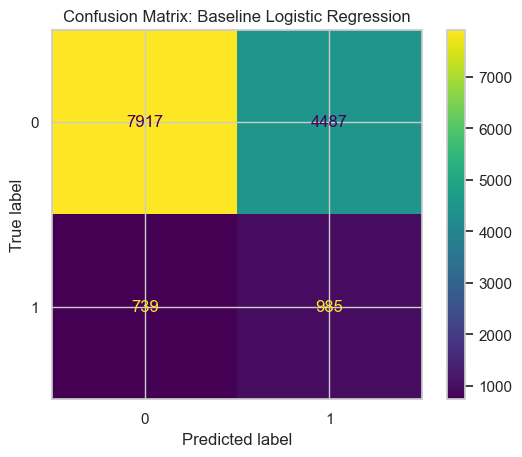

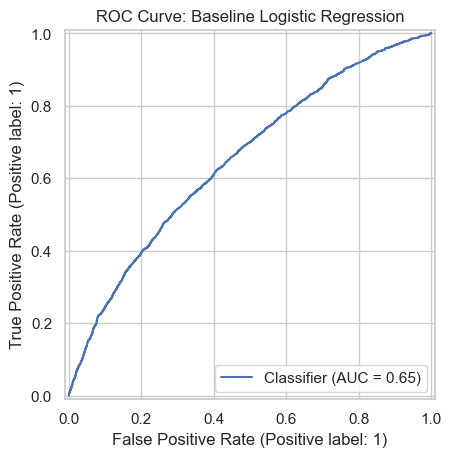


 Baseline Decision Tree
              precision    recall  f1-score   support

           0       0.92      0.59      0.72     12404
           1       0.17      0.62      0.27      1724

    accuracy                           0.59     14128
   macro avg       0.54      0.60      0.49     14128
weighted avg       0.83      0.59      0.66     14128



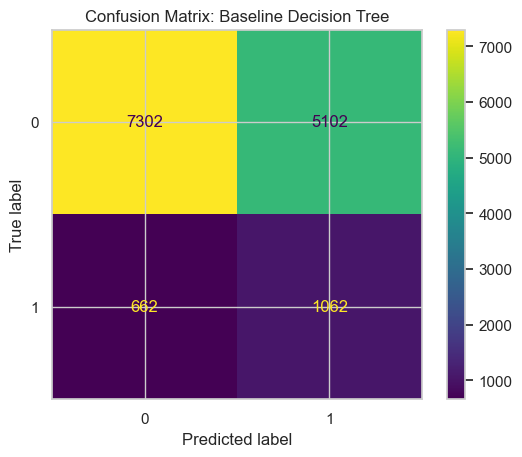

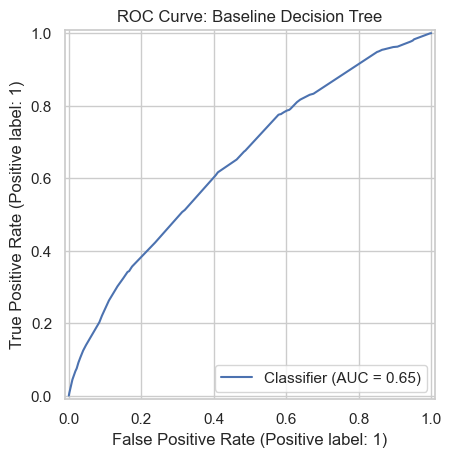

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline Logistic Regression,0.630096,0.180007,0.571346,0.273763,0.650825
1,Baseline Decision Tree,0.592016,0.172291,0.616009,0.269270,0.645079


In [24]:
baseline_features = baseline_numeric_features + baseline_categorical_features

baseline_logistic = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    baseline_numeric_features,
    baseline_categorical_features,
)

baseline_tree = make_pipeline(
    DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    baseline_numeric_features,
    baseline_categorical_features,
)

baseline_logistic.fit(X_train[baseline_features], y_train)
baseline_tree.fit(X_train[baseline_features], y_train)

baseline_results = []
baseline_results.append(evaluate_model("Baseline Logistic Regression", baseline_logistic, X_test[baseline_features], y_test))
baseline_results.append(evaluate_model("Baseline Decision Tree", baseline_tree, X_test[baseline_features], y_test))

pd.DataFrame(baseline_results)

## 9. Enriched Models: Crash Variables + Traffic Volume Variables


 Enriched Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.64      0.76     12404
           1       0.18      0.56      0.27      1724

    accuracy                           0.63     14128
   macro avg       0.55      0.60      0.51     14128
weighted avg       0.82      0.63      0.70     14128



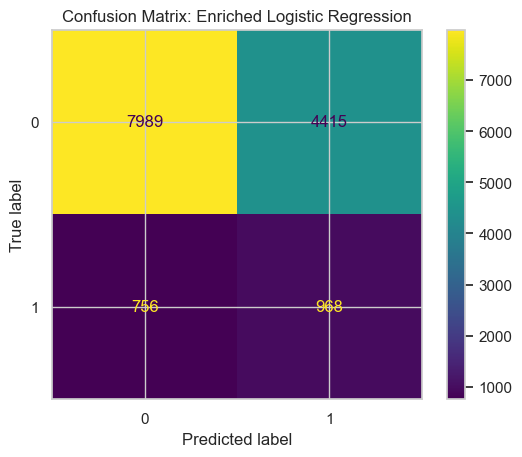

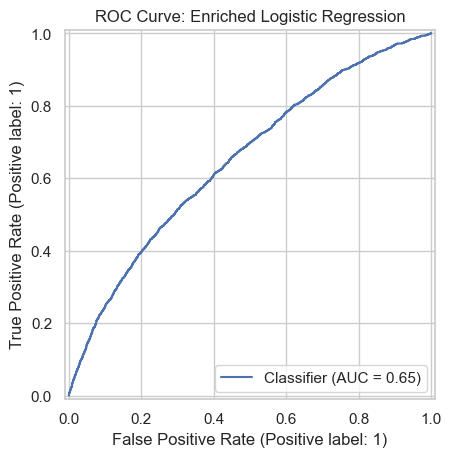


 Enriched Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.64      0.75     12404
           1       0.18      0.56      0.27      1724

    accuracy                           0.63     14128
   macro avg       0.55      0.60      0.51     14128
weighted avg       0.82      0.63      0.69     14128



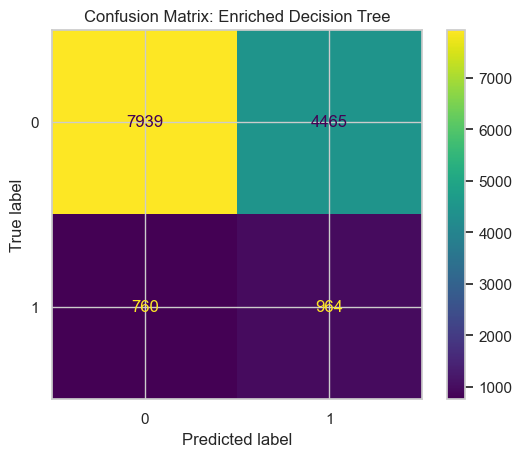

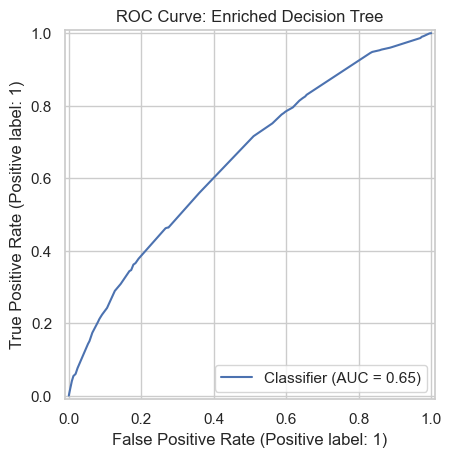

,model,accuracy,precision,recall,f1,roc_auc
0,Enriched Logistic Regression,0.633989,0.179825,0.561485,0.272407,0.650043
1,Enriched Decision Tree,0.630167,0.177565,0.559165,0.269537,0.647993


In [26]:
enriched_features = enriched_numeric_features + enriched_categorical_features

enriched_logistic = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    enriched_numeric_features,
    enriched_categorical_features,
)

enriched_tree = make_pipeline(
    DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    enriched_numeric_features,
    enriched_categorical_features,
)

enriched_logistic.fit(X_train[enriched_features], y_train)
enriched_tree.fit(X_train[enriched_features], y_train)

enriched_results = []
enriched_results.append(evaluate_model("Enriched Logistic Regression", enriched_logistic, X_test[enriched_features], y_test))
enriched_results.append(evaluate_model("Enriched Decision Tree", enriched_tree, X_test[enriched_features], y_test))

pd.DataFrame(enriched_results)

## 10. Cross-Validation Comparison

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_models = {
    "Baseline Logistic Regression": (baseline_logistic, baseline_features),
    "Baseline Decision Tree": (baseline_tree, baseline_features),
    "Enriched Logistic Regression": (enriched_logistic, enriched_features),
    "Enriched Decision Tree": (enriched_tree, enriched_features),
}

cv_rows = []
for name, (model, features) in cv_models.items():
    scores = cross_validate(model, X[features], y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
cv_results

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Enriched Logistic Regression,0.636902,0.003940,0.188182,0.001570,0.596345,0.009635,0.286076,0.002497,0.665362,0.006201
0,Baseline Logistic Regression,0.632039,0.003814,0.186959,0.002317,0.602089,0.011887,0.285311,0.003757,0.666986,0.005353
1,Baseline Decision Tree,0.661198,0.058810,0.193661,0.013546,0.548999,0.089238,0.283806,0.007809,0.659028,0.006020
3,Enriched Decision Tree,0.645759,0.074676,0.190239,0.015915,0.563621,0.113358,0.280093,0.004440,0.654802,0.005723


## 11. Hyperparameter Tuning for Decision Tree

This satisfies the Assignment 4 requirement to optimise models.

Best parameters: {'model__max_depth': 9, 'model__min_samples_leaf': 200}
Best CV F1: 0.2844221856824424

 Tuned Enriched Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.66      0.76     12404
           1       0.18      0.55      0.27      1724

    accuracy                           0.64     14128
   macro avg       0.55      0.60      0.52     14128
weighted avg       0.82      0.64      0.70     14128



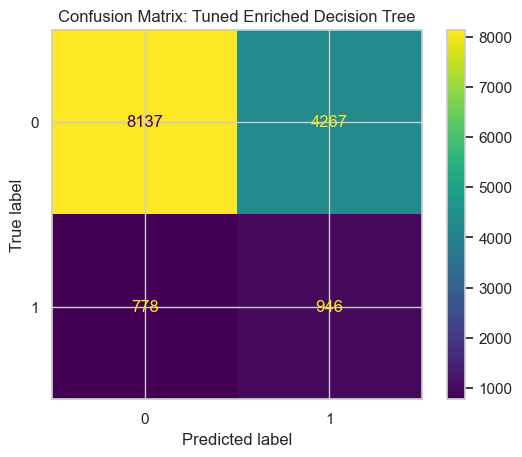

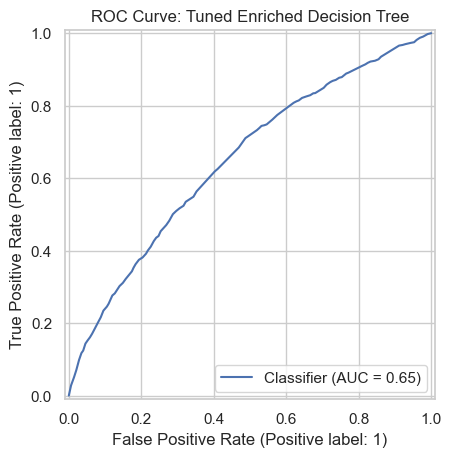

{'model': 'Tuned Enriched Decision Tree',
 'accuracy': 0.6429077010192525,
 'precision': 0.18146940341454057,
 'recall': 0.548723897911833,
 'f1': 0.2727403776848782,
 'roc_auc': 0.6487678269340553}

In [30]:
tree_param_grid = {
    "model__max_depth": [3, 5, 7, 9, None],
    "model__min_samples_leaf": [50, 100, 200],
}

tree_grid = GridSearchCV(
    estimator=enriched_tree,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)

tree_grid.fit(X_train[enriched_features], y_train)

print("Best parameters:", tree_grid.best_params_)
print("Best CV F1:", tree_grid.best_score_)

tuned_tree_result = evaluate_model(
    "Tuned Enriched Decision Tree",
    tree_grid.best_estimator_,
    X_test[enriched_features],
    y_test,
)

tuned_tree_result

## 12. Final Results Table

In [32]:
all_results = pd.DataFrame(baseline_results + enriched_results + [tuned_tree_result])
all_results = all_results.sort_values("f1", ascending=False)
all_results

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline Logistic Regression,0.630096,0.180007,0.571346,0.273763,0.650825
4,Tuned Enriched Decision Tree,0.642908,0.181469,0.548724,0.272740,0.648768
2,Enriched Logistic Regression,0.633989,0.179825,0.561485,0.272407,0.650043
3,Enriched Decision Tree,0.630167,0.177565,0.559165,0.269537,0.647993
1,Baseline Decision Tree,0.592016,0.172291,0.616009,0.269270,0.645079


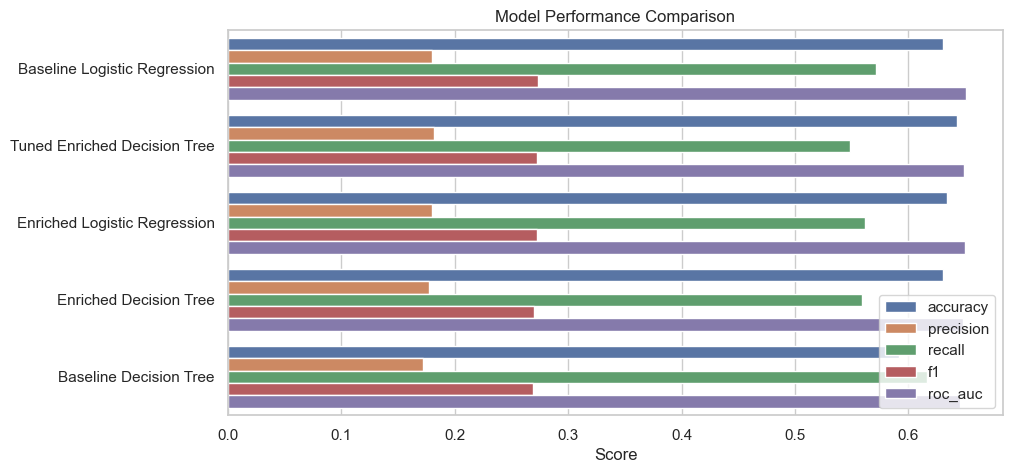

In [33]:
plt.figure(figsize=(10, 5))
plot_df = all_results.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="score", y="model", hue="metric")
plt.title("Model Performance Comparison")
plt.xlabel("Score")
plt.ylabel("")
plt.legend(loc="lower right")
plt.show()

## 13. Feature Importance / Interpretation

,feature,importance
0,num__No. of traffic units involved,0.375698
1,num__Speed_limit_num,0.205580
17,cat__Urbanisation_Sydney metro. area,0.057262
7,num__all_vehicles_all_days,0.055698
28,cat__Type of location_T-junction,0.041452
30,cat__Type of location_X-intersection,0.038214
15,cat__Urbanisation_Country urban,0.032965
20,cat__Type of location_2-way undivided,0.032295
6,num__Day_num,0.032260
5,num__Month_num,0.030462


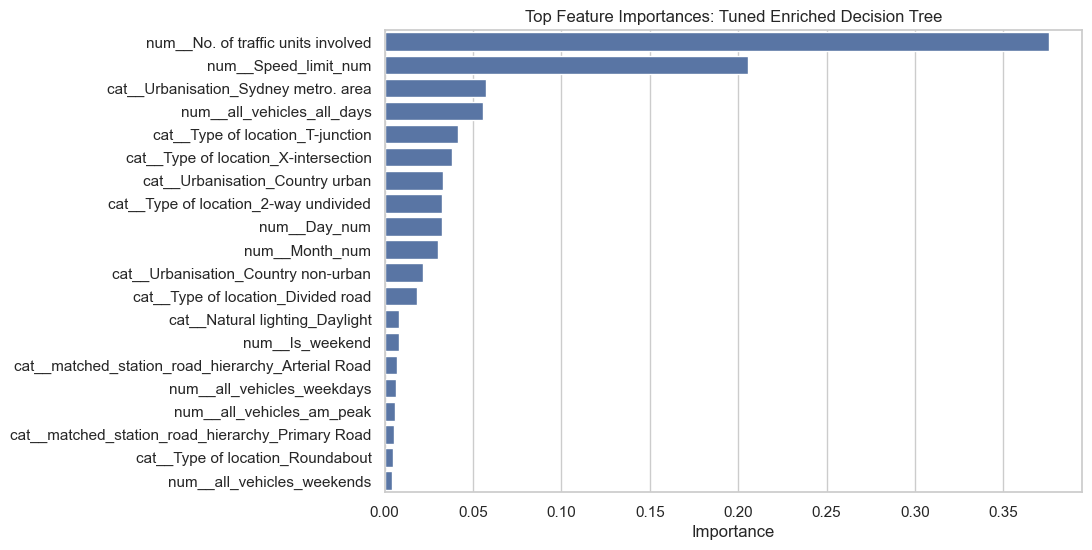

In [35]:
best_tree = tree_grid.best_estimator_
preprocessor = best_tree.named_steps["preprocess"]
tree_model = best_tree.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importances = tree_model.feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

display(feature_importance)

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance, x="importance", y="feature")
plt.title("Top Feature Importances: Tuned Enriched Decision Tree")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

## 14. Export Results

These CSV files can be used in the final report.

In [37]:
OUTPUT_DIR = Path("rq4_model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

all_results.to_csv(OUTPUT_DIR / "rq4_model_test_results.csv", index=False)
cv_results.to_csv(OUTPUT_DIR / "rq4_cross_validation_results.csv", index=False)
feature_importance.to_csv(OUTPUT_DIR / "rq4_feature_importance.csv", index=False)
target_summary.to_csv(OUTPUT_DIR / "rq4_target_distribution.csv")
tu_summary.to_csv(OUTPUT_DIR / "rq4_traffic_units_summary.csv", index=False)
volume_summary.to_csv(OUTPUT_DIR / "rq4_traffic_volume_summary.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: /Users/alanjoshi/Downloads/rq4_model_outputs


## Notes for Report Interpretation

After running the notebook, use the tables above to answer:

- Did the enriched model improve F1-score, recall, or ROC-AUC compared with the baseline model?
- Which predictors were most important?
- Did traffic-volume variables help classify high-injury crashes?
- What are the limitations of matching crash locations to nearest traffic-count stations?